# 🏛️ Capstone: multi-strategy portfolio

## 🧭 tl;dr

This notebook combines a small set of representative sleeves into one research portfolio:

- **SPY buy and hold** — the equity benchmark.
- **60/40** — a simple stock/bond control.
- **12–1 cross-sectional momentum** — hold the strongest liquid markets.
- **Trend rotation** — use a long-term trend gate and a defensive fallback.
- **Inverse-volatility allocation** — give less capital to noisier assets.

The goal is not to manufacture a high Sharpe ratio. It is to ask a more useful portfolio question:

> Does combining different sources of risk produce a smoother result than any one sleeve by itself, after realistic costs?

The notebook reports correlation, rolling Sharpe, risk contribution, drawdowns, benchmark comparisons, and cost sensitivity.

> **Educational research only. Not financial advice. Historical backtests are not guarantees of future performance.**

## 💡 Why a capstone portfolio?

A strategy can look attractive in isolation because it happens to fit one period. A portfolio view makes the tradeoffs visible:

1. **Correlation** asks whether sleeves actually diversify one another.
2. **Risk contribution** asks which sleeves drive portfolio volatility.
3. **Rolling Sharpe** shows whether the result is stable or concentrated in one era.
4. **Drawdown comparisons** show what an investor experiences during stress.
5. **Cost sensitivity** checks whether the idea survives implementation friction.

This is still a simplified research portfolio. It uses liquid ETF proxies, daily adjusted closes, monthly allocation decisions, and no leverage beyond 100% absolute exposure.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import split_time_series
from src.data import load_price_panel
from src.metrics import calculate_metrics
from src.portfolio import (
    cross_sectional_momentum_weights,
    inverse_volatility_weights,
    run_portfolio_backtest,
    trend_following_rotation_weights,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

## 📦 Data and assumptions

The live run requests adjusted daily ETF prices from Yahoo Finance. Adjusted prices are useful for a teaching backtest because distributions and splits are reflected in the price series, but they are not the same as point-in-time institutional data.

If the download is unavailable, the cell uses a deterministic synthetic panel so the notebook still demonstrates the workflow. Synthetic output is explicitly labeled and must not be treated as market evidence.

**Assumptions**

- Sample: January 2006 through December 2025.
- Rebalance: monthly, with a one-trading-day execution delay from the shared portfolio engine.
- Default cost: 10 basis points per unit of absolute exposure change.
- Benchmark: SPY buy and hold.
- No leverage, financing, borrow fees, taxes, or market impact model.

In [2]:
TICKERS = ["SPY", "QQQ", "EFA", "EEM", "TLT", "IEF", "GLD", "DBC", "VNQ", "XLF", "XLK"]
START, END = "2006-01-01", "2026-01-01"

def make_demo_panel(tickers, periods=5000, seed=47):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range("2006-01-03", periods=periods)
    common = rng.normal(0.00018, 0.0085, periods)
    panel = {}
    for i, ticker in enumerate(tickers):
        idio = rng.normal(0.00005 + i * 0.00001, 0.006 + (i % 3) * 0.001, periods)
        if ticker in {"TLT", "IEF"}:
            daily = -0.18 * common + 0.55 * idio
        else:
            daily = (0.45 + 0.04 * (i % 4)) * common + 0.55 * idio
        panel[ticker] = 100 * np.exp(np.cumsum(daily))
    return pd.DataFrame(panel, index=dates)

try:
    close = load_price_panel(TICKERS, START, END).dropna()
    data_source = "Yahoo Finance adjusted daily ETF closes"
except Exception as exc:
    close = make_demo_panel(TICKERS)
    data_source = f"deterministic synthetic demonstration panel ({type(exc).__name__})"

benchmark = close["SPY"].pct_change().fillna(0.0).rename("SPY")
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())

Data source: Yahoo Finance adjusted daily ETF closes
Observations: 5,008 | 2006-02-06 to 2025-12-31


,DBC,EEM,EFA,GLD,IEF,QQQ,SPY,TLT,VNQ,XLF,XLK
Date,,,,,,,,,,,
2006-02-06,19.185097,21.803120,33.987091,56.720001,48.517372,34.846825,86.932236,47.462002,27.023003,17.145830,8.176652
2006-02-07,18.630159,21.231091,33.735298,54.599998,48.458897,34.693111,86.163200,47.237823,26.810501,17.032141,8.153530
2006-02-08,18.550882,21.297094,33.855721,54.830002,48.429607,35.094467,86.946007,47.128338,26.691500,17.140411,8.311510
2006-02-09,18.725288,21.352098,33.921413,56.180000,48.476463,34.761433,86.801788,47.342102,26.818991,17.183725,8.272979
2006-02-10,18.384398,21.319096,33.844784,54.790001,48.336040,34.974892,86.959724,47.081409,26.844500,17.281176,8.338487


## 📐 Exact sleeve rules

All rules use information available through the prior close and are implemented through the shared portfolio engine.

- **SPY buy and hold:** 100% SPY.
- **60/40:** 60% SPY and 40% TLT, rebalanced monthly.
- **12–1 momentum:** rank the asset universe by the prior 252-day return, skip the most recent 21 trading days, and equal-weight the top three.
- **Trend rotation:** among risk assets, keep only those above their prior 200-day average and select the strongest positive 126-day momentum asset; if no risk asset qualifies, look for a positive-momentum defensive asset.
- **Inverse volatility:** estimate trailing 60-day volatility using only prior returns and weight assets in inverse proportion to that risk.

The capstone portfolio is an equal-capital blend of the five sleeves. Equal capital is deliberately simple; later work can test risk-budgeted allocations.

In [3]:
risk_assets = ("SPY", "QQQ", "EFA", "EEM", "VNQ", "XLF", "XLK")
defensive_assets = ("TLT", "IEF", "GLD")

weights = {}

weights["SPY buy & hold"] = pd.DataFrame(0.0, index=close.index, columns=close.columns)
weights["SPY buy & hold"]["SPY"] = 1.0

weights["60/40"] = pd.DataFrame(0.0, index=close.index, columns=close.columns)
weights["60/40"]["SPY"] = 0.60
weights["60/40"]["TLT"] = 0.40

weights["12–1 momentum"] = cross_sectional_momentum_weights(
    close, lookback=252, skip_recent=21, top_n=3
)
weights["trend rotation"] = trend_following_rotation_weights(
    close,
    trend_window=200,
    momentum_lookback=126,
    top_n=1,
    risk_assets=risk_assets,
    defensive_assets=defensive_assets,
)
weights["inverse volatility"] = inverse_volatility_weights(close, lookback=60)

for name, frame in weights.items():
    exposure = frame.abs().sum(axis=1)
    print(f"{name:22s} | max absolute exposure: {exposure.max():.2f} | non-zero days: {(exposure > 0).sum():,}")

SPY buy & hold         | max absolute exposure: 1.00 | non-zero days: 5,008
60/40                  | max absolute exposure: 1.00 | non-zero days: 5,008
12–1 momentum          | max absolute exposure: 1.00 | non-zero days: 4,719
trend rotation         | max absolute exposure: 1.00 | non-zero days: 4,735
inverse volatility     | max absolute exposure: 1.00 | non-zero days: 4,928


## 🧪 Run the sleeves before and after costs

The portfolio engine records:

- **gross returns** before trading costs;
- **turnover** as the sum of absolute weight changes;
- **net returns** after the stated cost;
- **held weights** after the one-bar execution delay.

The same inputs are run with several cost assumptions later so a positive gross result cannot hide a fragile implementation.

In [4]:
def run_sleeves(transaction_cost_bps):
    return {
        name: run_portfolio_backtest(
            close,
            target_weights,
            transaction_cost_bps=transaction_cost_bps,
            benchmark_returns=benchmark,
        )
        for name, target_weights in weights.items()
    }

sleeve_results = run_sleeves(transaction_cost_bps=10.0)
gross_returns = pd.DataFrame({
    name: result.frame["gross_returns"] for name, result in sleeve_results.items()
})
net_returns = pd.DataFrame({
    name: result.frame["net_returns"] for name, result in sleeve_results.items()
})
turnover = pd.DataFrame({
    name: result.frame["turnover"] for name, result in sleeve_results.items()
})

ensemble_gross = gross_returns.mean(axis=1).rename("capstone ensemble")
ensemble_net = net_returns.mean(axis=1).rename("capstone ensemble")
ensemble_turnover = turnover.mean(axis=1).rename("capstone ensemble")

def series_metrics(returns, turnover_series=None):
    return dict(calculate_metrics(
        returns,
        benchmark_returns=benchmark.reindex(returns.index).fillna(0.0),
        positions=pd.Series(1.0, index=returns.index),
        turnover=turnover_series,
        annualization=252,
    ))

rows = []
for name in weights:
    for label, series, t in [
        ("gross", gross_returns[name], turnover[name]),
        ("after costs", net_returns[name], turnover[name]),
    ]:
        rows.append({"strategy": name, "version": label, **series_metrics(series, t)})
for label, series in [("gross", ensemble_gross), ("after costs", ensemble_net)]:
    rows.append({"strategy": "capstone ensemble", "version": label, **series_metrics(series, ensemble_turnover)})

performance = pd.DataFrame(rows).set_index(["strategy", "version"])
display(performance[[
    "annualized_return", "annualized_volatility", "sharpe_ratio",
    "sortino_ratio", "max_drawdown", "calmar_ratio",
    "annualized_turnover", "total_return_after_costs",
]].style.format({
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "sortino_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "calmar_ratio": "{:.2f}",
    "annualized_turnover": "{:.2f}",
    "total_return_after_costs": "{:.2%}",
}))

## 📉 Equity curves and drawdowns

A smooth-looking equity curve can be misleading if one period dominates the full sample. Read the full-sample charts together with the rolling Sharpe and chronological split below.

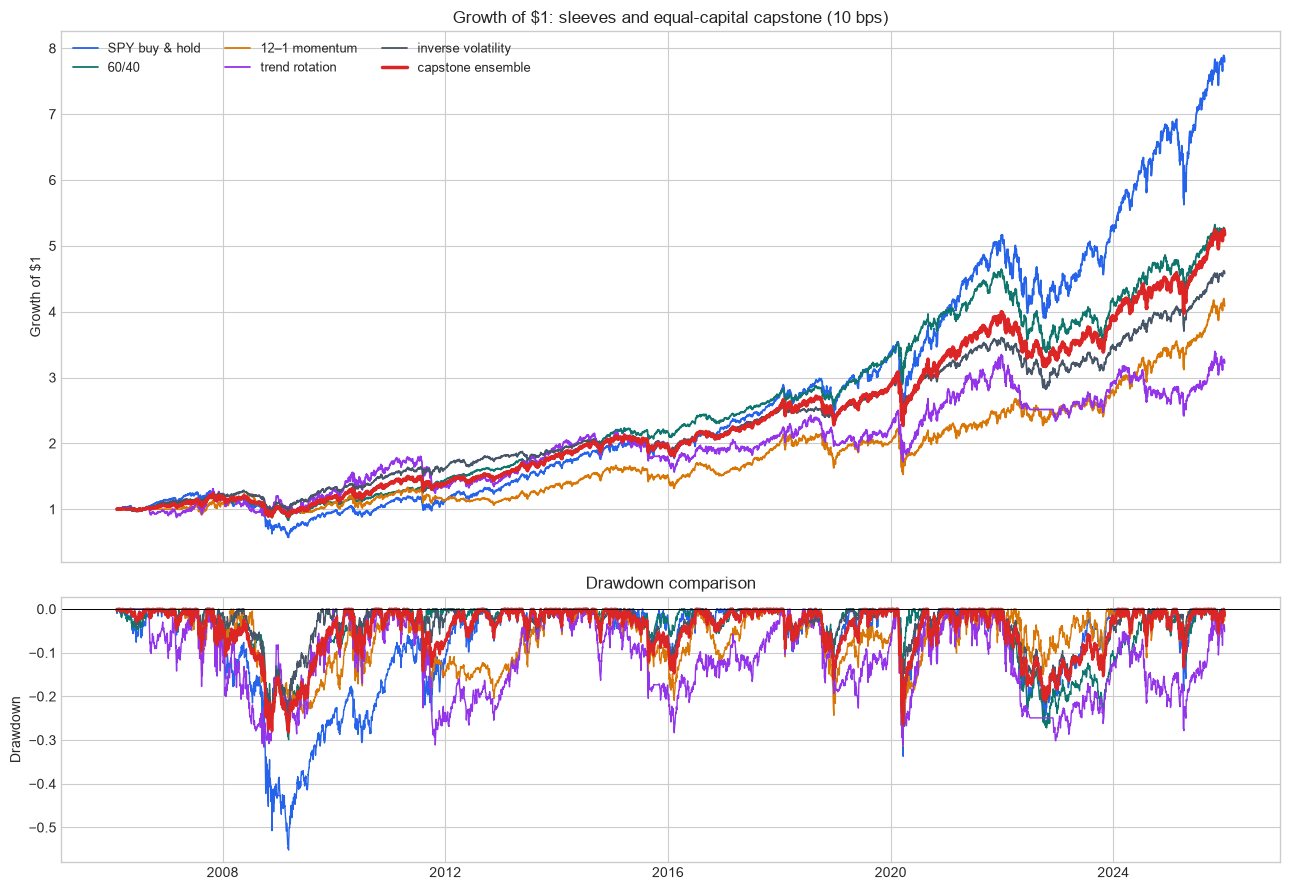

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
colors = ["#2563EB", "#0F766E", "#D97706", "#9333EA", "#475569", "#111827"]
for (name, series), color in zip(net_returns.items(), colors):
    axes[0].plot((1 + series).cumprod(), label=name, lw=1.3, color=color)
axes[0].plot((1 + ensemble_net).cumprod(), label="capstone ensemble", lw=2.5, color="#DC2626")
axes[0].set_title("Growth of $1: sleeves and equal-capital capstone (10 bps)")
axes[0].set_ylabel("Growth of $1")
axes[0].legend(ncol=3, fontsize=9)

for (name, series), color in zip(net_returns.items(), colors):
    equity = (1 + series).cumprod()
    axes[1].plot(equity / equity.cummax() - 1, label=name, lw=1.0, color=color)
ensemble_equity = (1 + ensemble_net).cumprod()
axes[1].plot(ensemble_equity / ensemble_equity.cummax() - 1, label="capstone ensemble", lw=2.0, color="#DC2626")
axes[1].set_title("Drawdown comparison")
axes[1].set_ylabel("Drawdown")
axes[1].axhline(0, color="black", lw=0.7)
plt.tight_layout()
plt.show()

## 🔁 Rolling Sharpe ratio

The rolling metric is intentionally noisy. That is useful: it shows how often the apparent edge disappears rather than averaging those changes away.

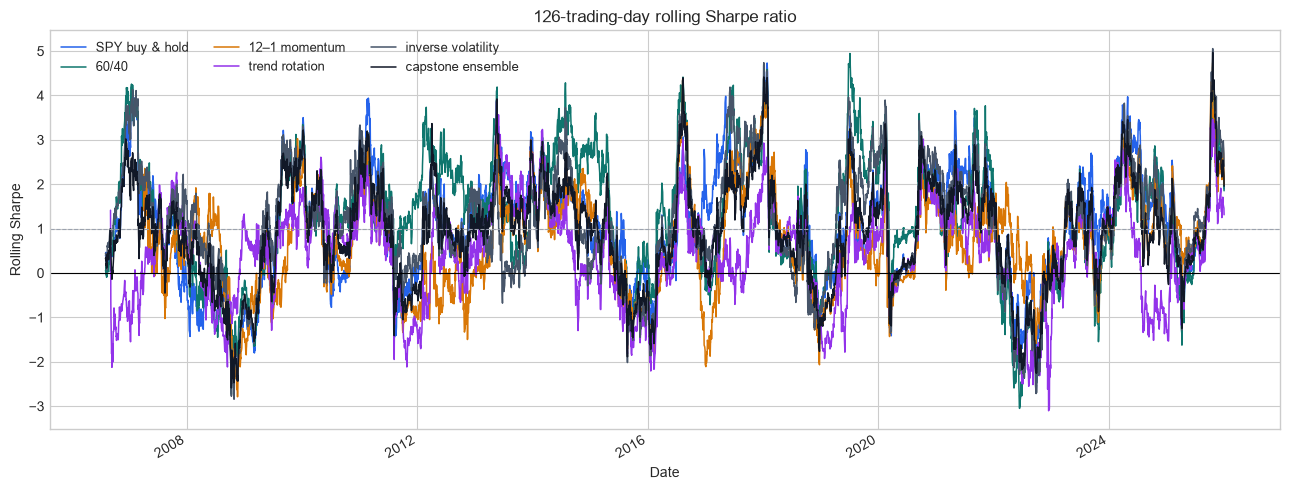

In [6]:
rolling_sharpe = net_returns.join(ensemble_net).rolling(126).mean()
rolling_sharpe = rolling_sharpe.div(net_returns.join(ensemble_net).rolling(126).std()).mul(np.sqrt(252))

ax = rolling_sharpe.plot(figsize=(13, 5), lw=1.1, color=colors + ["#DC2626"])
ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="#9CA3AF", lw=0.8, ls="--")
ax.set_title("126-trading-day rolling Sharpe ratio")
ax.set_ylabel("Rolling Sharpe")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

## 🧩 Correlation and risk contribution

Correlation describes co-movement, but it does not tell us how much volatility each sleeve contributes. A low-return, high-volatility sleeve can dominate risk even when capital is split equally.

Risk contribution below uses the full-sample covariance matrix of the after-cost daily sleeve returns and equal capital weights. It is a descriptive diagnostic, not a portfolio optimizer.

In [7]:
correlation = net_returns.join(ensemble_net).corr()
display(correlation.round(2).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

sleeve_names = list(net_returns.columns)
covariance = net_returns[sleeve_names].cov() * 252
capital_weights = np.repeat(1.0 / len(sleeve_names), len(sleeve_names))
portfolio_variance = float(capital_weights @ covariance.to_numpy() @ capital_weights)
marginal = covariance.to_numpy() @ capital_weights
risk_contribution = capital_weights * marginal / portfolio_variance if portfolio_variance > 0 else np.zeros_like(capital_weights)

risk_table = pd.DataFrame({
    "capital_weight": capital_weights,
    "risk_contribution": risk_contribution,
}, index=sleeve_names)
display(risk_table.style.format("{:.2%}"))

print(
    "Interpretation: capital weights are equal by construction, but risk contributions "
    "need not be equal because the sleeves have different volatility and correlations."
)

,SPY buy & hold,60/40,12–1 momentum,trend rotation,inverse volatility,capstone ensemble
SPY buy & hold,1.000000,0.870000,0.660000,0.570000,0.890000,0.900000
60/40,0.870000,1.000000,0.630000,0.510000,0.910000,0.860000
12–1 momentum,0.660000,0.630000,1.000000,0.690000,0.720000,0.860000
trend rotation,0.570000,0.510000,0.690000,1.000000,0.610000,0.820000
inverse volatility,0.890000,0.910000,0.720000,0.610000,1.000000,0.920000
capstone ensemble,0.900000,0.860000,0.860000,0.820000,0.920000,1.000000


,capital_weight,risk_contribution
SPY buy & hold,20.00%,25.42%
60/40,20.00%,14.13%
12–1 momentum,20.00%,20.75%
trend rotation,20.00%,25.73%
inverse volatility,20.00%,13.98%


Interpretation: capital weights are equal by construction, but risk contributions need not be equal because the sleeves have different volatility and correlations.


## 💸 Cost sensitivity

A robust conclusion should not depend on one arbitrary fee assumption. The table reruns every sleeve at 0, 5, 10, 25, and 50 basis points per unit of absolute weight change, then averages the net sleeve returns into the capstone ensemble.

In [8]:
cost_rows = []
for cost in [0, 5, 10, 25, 50]:
    results = run_sleeves(transaction_cost_bps=cost)
    returns = pd.DataFrame({name: result.frame["net_returns"] for name, result in results.items()})
    ensemble = returns.mean(axis=1)
    cost_rows.append({
        "cost_bps": cost,
        **series_metrics(ensemble, returns.diff().abs().sum(axis=1) / len(returns.columns)),
    })
cost_table = pd.DataFrame(cost_rows).set_index("cost_bps")
display(cost_table[[
    "annualized_return", "annualized_volatility", "sharpe_ratio",
    "max_drawdown", "annualized_turnover", "total_return_after_costs",
]].style.format({
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "sortino_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "calmar_ratio": "{:.2f}",
    "annualized_turnover": "{:.2f}",
    "total_return_after_costs": "{:.2%}",
}))

,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,annualized_turnover,total_return_after_costs
cost_bps,,,,,,
0,8.95%,13.76%,0.69,-27.94%,2.45,449.66%
5,8.78%,13.76%,0.68,-28.08%,2.45,432.96%
10,8.62%,13.76%,0.67,-28.23%,2.45,416.76%
25,8.11%,13.76%,0.64,-28.66%,2.45,371.04%
50,7.27%,13.77%,0.58,-29.37%,2.45,303.60%


## 🗓️ Chronological train / validation / test comparison

The split is chronological, not random:

- **Train** is for learning the basic behavior.
- **Validation** is for choosing reasonable parameters.
- **Test** is the final untouched period in this notebook.

The capstone is intentionally not optimized on the test period.

In [9]:
split_indices = split_time_series(pd.DataFrame(index=net_returns.index))
period_rows = []
period_series = {
    "capstone ensemble": ensemble_net,
    "SPY buy & hold": net_returns["SPY buy & hold"],
    "60/40": net_returns["60/40"],
    "12–1 momentum": net_returns["12–1 momentum"],
    "trend rotation": net_returns["trend rotation"],
}
for period, frame in split_indices.items():
    for name, series in period_series.items():
        period_returns = series.loc[frame.index]
        period_rows.append({
            "period": period,
            "strategy": name,
            **series_metrics(period_returns, turnover.loc[frame.index].mean(axis=1)),
        })
split_table = pd.DataFrame(period_rows).set_index(["period", "strategy"])
display(split_table[[
    "annualized_return", "annualized_volatility", "sharpe_ratio",
    "max_drawdown", "total_return_after_costs",
]].style.format({
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "sortino_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "calmar_ratio": "{:.2f}",
    "annualized_turnover": "{:.2f}",
    "total_return_after_costs": "{:.2%}",
}))

## 🧠 What went well and what went wrong?

**What went well**

- The notebook makes diversification measurable rather than assuming it.
- The equal-capital ensemble is compared with both SPY and 60/40.
- Cost sensitivity and chronological splits make it harder to overinterpret one headline Sharpe ratio.
- Risk contribution exposes whether the ensemble is secretly just an equity bet.

**What went wrong or remains incomplete**

- ETF proxies do not reproduce a real hedge fund’s security selection, financing, leverage, or execution.
- The sleeve mix is hand-selected. It is not an optimized asset allocation.
- Correlations and risk contributions are sample estimates and can change materially.
- The fallback demo data validates code only; it is not evidence.
- A stronger capstone would add walk-forward re-estimation, point-in-time holdings, taxes, financing, and a formal portfolio-level multiple-testing audit.

The most important result is therefore the comparison table—not whichever sleeve has the highest Sharpe in this sample.